In [1]:
!pip install torch torchvision pillow matplotlib

In [74]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models

from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

In [75]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [76]:
img_size = 512

transform = transforms.Compose([
    transforms.Resize((img_size,img_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [77]:
def load_img(path):

    img = Image.open(path).convert("RGB")
    img = transform(img).unsqueeze(0)

    return img.to(device)

In [78]:
def denorm(t):

    mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1).to(t.device)
    std = torch.tensor([0.229,0.224,0.225]).view(3,1,1).to(t.device)

    t = t * std + mean
    return torch.clamp(t,0,1)

In [79]:
content = load_img("content.jpg")
style = load_img("starry_night.jpg")

In [80]:
vgg = models.vgg19(pretrained=True).features.to(device).eval()

for p in vgg.parameters():
    p.requires_grad=False

In [81]:
layers = {
    '0':'conv1',
    '5':'conv2',
    '10':'conv3',
    '19':'conv4',
    '21':'content',
    '28':'conv5'
}

def get_features(x):

    feats = {}

    for name,layer in vgg._modules.items():

        x = layer(x)

        if name in layers:
            feats[layers[name]] = x

    return feats

In [82]:
def gram(x):

    b,c,h,w = x.size()

    f = x.view(c,h*w)

    G = torch.mm(f,f.t())

    return G/(c*h*w)

In [83]:
content_f = get_features(content)
style_f = get_features(style)

style_grams = {l:gram(style_f[l]) for l in style_f}

In [84]:
gen = content.clone().requires_grad_(True).to(device)

In [85]:
optimizer = optim.LBFGS([gen])

style_w = 1e6
content_w = 1
steps = 300

In [86]:
run=[0]

while run[0] <= steps:

    def closure():

        gen.data.clamp_(-2,2)

        optimizer.zero_grad()

        g_feat = get_features(gen)

        c_loss = torch.mean(
            (g_feat['content']-content_f['content'])**2
        )

        s_loss = 0

        for l in style_f:

            g = gram(g_feat[l])
            s = style_grams[l]

            s_loss += torch.mean((g-s)**2)

        loss = content_w*c_loss + style_w*s_loss

        loss.backward()

        run[0]+=1

        if run[0] % 50 ==0:
            print("step",run[0],"loss",loss.item())

        return loss

    optimizer.step(closure)

step 50 loss 17.732213973999023
step 100 loss 9.748456954956055
step 150 loss 8.806981086730957
step 200 loss 8.42345905303955
step 250 loss 8.219173431396484
step 300 loss 8.084500312805176


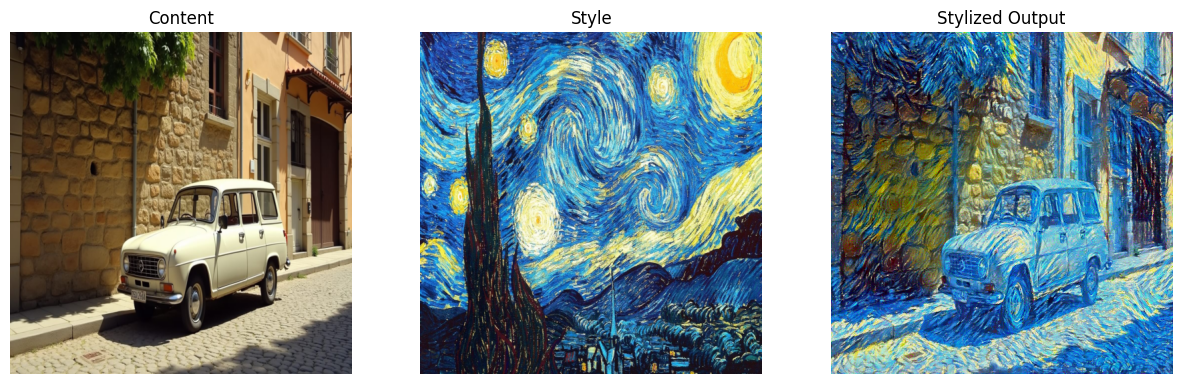

In [87]:
fig,ax = plt.subplots(1,3,figsize=(15,5))

ax[0].imshow(denorm(content.squeeze()).permute(1,2,0).cpu())
ax[0].set_title("Content")
ax[0].axis("off")

ax[1].imshow(denorm(style.squeeze()).permute(1,2,0).cpu())
ax[1].set_title("Style")
ax[1].axis("off")

ax[2].imshow(denorm(gen.detach().squeeze()).permute(1,2,0).cpu())
ax[2].set_title("Stylized Output")
ax[2].axis("off")

plt.show()

In [93]:
content = load_img("content2.jpg")
style = load_img("art_style.jpg")

In [94]:
content_f = get_features(content)
style_f = get_features(style)

style_grams = {layer: gram(style_f[layer]) for layer in style_f}

In [95]:
gen = content.clone().requires_grad_(True).to(device)

In [96]:
optimizer = torch.optim.LBFGS([gen])

run = [0]

while run[0] <= steps:

    def closure():

        gen.data.clamp_(-2,2)

        optimizer.zero_grad()

        g_feat = get_features(gen)

        c_loss = torch.mean(
            (g_feat['content'] - content_f['content'])**2
        )

        s_loss = 0

        for l in style_f:
            g = gram(g_feat[l])
            s = style_grams[l]
            s_loss += torch.mean((g - s)**2)

        loss = content_w*c_loss + style_w*s_loss

        loss.backward()

        run[0]+=1

        if run[0] % 50 == 0:
            print("step:", run[0], "loss:", loss.item())

        return loss

    optimizer.step(closure)

step: 50 loss: 21.6705265045166
step: 100 loss: 14.386159896850586
step: 150 loss: 11.297721862792969
step: 200 loss: 9.942758560180664
step: 250 loss: 9.323987007141113
step: 300 loss: 9.046066284179688


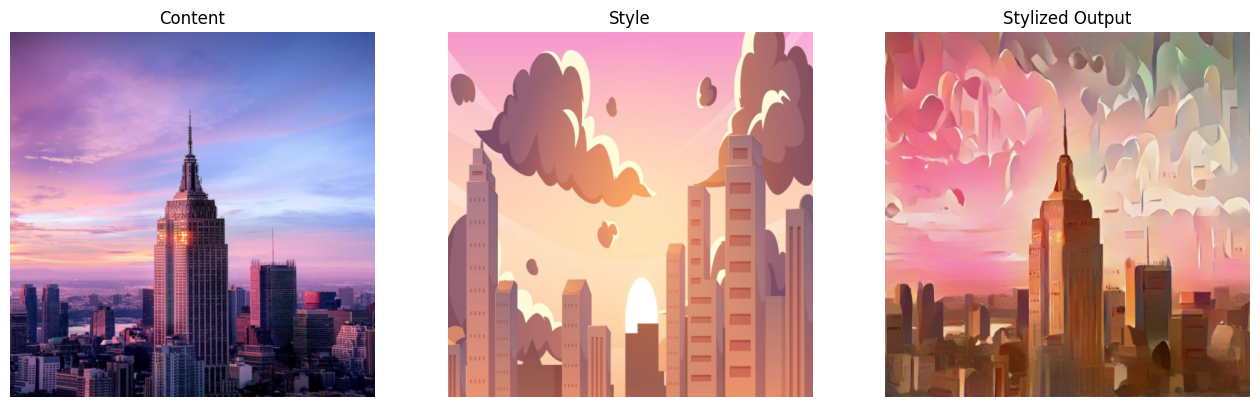

In [97]:
fig,ax = plt.subplots(1,3,figsize=(16,6))

ax[0].imshow(denorm(content.squeeze()).permute(1,2,0).cpu())
ax[0].set_title("Content")
ax[0].axis("off")

ax[1].imshow(denorm(style.squeeze()).permute(1,2,0).cpu())
ax[1].set_title("Style")
ax[1].axis("off")

ax[2].imshow(denorm(gen.detach().squeeze()).permute(1,2,0).cpu())
ax[2].set_title("Stylized Output")
ax[2].axis("off")

plt.show()